# Retail ABM - Simulation Results Analysis & Reality Comparison
This notebook analyzes the synthetic visits generated by the model and compares them 
to empirical data (Retail Centre POIs and NTS distribution).



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os

# CONFIGURATION
VISITS_LOG_PATH = r'C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\visits_log_1775568364.parquet'
AGENTS_PATH     = r'C:\Users\sgabalog\Documents\P3\Model\Utility\utility_scores_bulk_with_trips.parquet'
RETAIL_GPKG     = r'C:\Users\sgabalog\Documents\P3\Model\Retail Centre Data\retail_centre_type_counts.gpkg'



In [13]:
df_visits

,Day,AgentID,Trip_Type,Retail_Centre,Grocery_Mode,Transport_Mode,Travel_Time_Min,Utility_Modifier
0,1,162412,grocery,8813,convenience,drive,35.260193,0.95
1,1,323155,grocery,4877,bulk,drive,65.661079,1.05
2,1,2922,grocery,1245,bulk,walk,206.419693,1.05
3,1,10813,grocery,7375,bulk,pt,48.350502,0.95
4,1,553734,grocery,3882,convenience,pt,56.526485,1.05
...,...,...,...,...,...,...,...,...
27756910,30,452129,food_drink,6766,physical,pt,40.561584,1.05
27756911,30,55758,food_drink,7615,physical,drive,50.378185,1.05
27756912,30,505827,food_drink,1806,physical,walk,161.122787,0.95
27756913,30,26581,food_drink,4207,physical,walk,174.207947,1.05


In [22]:
print("Loading visits...")
df_visits = pd.read_parquet(VISITS_LOG_PATH)
print(f"Loaded {len(df_visits):,} visits.")

Loading visits...
Loaded 40,831 visits.


## 1. Load Data
We load the visits log, agent demographics (Age/Income), and Retail Centre GIS data.



In [23]:
df_visits
# Calculate the mean for all numerical columns
averages = df_visits.mean(numeric_only=True)

# Display the results
print("Average of numerical columns:")
print(averages)

Average of numerical columns:
Day                     15.520462
AgentID             319868.458965
Travel_Time_Min        119.303703
Utility_Modifier         1.000258
dtype: float64


In [24]:
# Identify categorical columns and print value counts for each
for col in df_visits.select_dtypes(include=['object', 'category']).columns:
    print(f"--- Counts for {col} ---")
    print(df_visits[col].value_counts())
    print("\n")

--- Counts for Trip_Type ---
Trip_Type
service          9533
grocery          9263
comparison       8431
entertainment    8420
food_drink       5184
Name: count, dtype: int64


--- Counts for Retail_Centre ---
Retail_Centre
90      644
97      604
1664    573
3883    558
2447    542
       ... 
8803     26
1179     19
3374     14
9576      7
8808      4
Name: count, Length: 237, dtype: int64


--- Counts for Grocery_Mode ---
Grocery_Mode
physical       31568
convenience     5796
bulk            3467
Name: count, dtype: int64


--- Counts for Transport_Mode ---
Transport_Mode
walk     16070
drive    12483
pt       12278
Name: count, dtype: int64




In [25]:
print("Loading visits...")
df_visits = pd.read_parquet(VISITS_LOG_PATH)
print(f"Loaded {len(df_visits):,} visits.")

print("Loading agent demographics...")
# Only load necessary columns to save memory
agent_cols = ['household', 'age_years', 'salary_yearly', 'Postcode']
df_agents = pd.read_parquet(AGENTS_PATH, columns=agent_cols)

print("Loading retail centre data...")
gdf_retail = gpd.read_file(RETAIL_GPKG, layer='retail_centre_counts')
# Clean RC_ID to match visits format
gdf_retail['RC_ID'] = gdf_retail['RC_ID'].astype(str).str.replace('.0', '', regex=False)



Loading visits...
Loaded 40,831 visits.
Loading agent demographics...
Loading retail centre data...


## 2. Global Distribution Check
Compare trip types and transport modes.



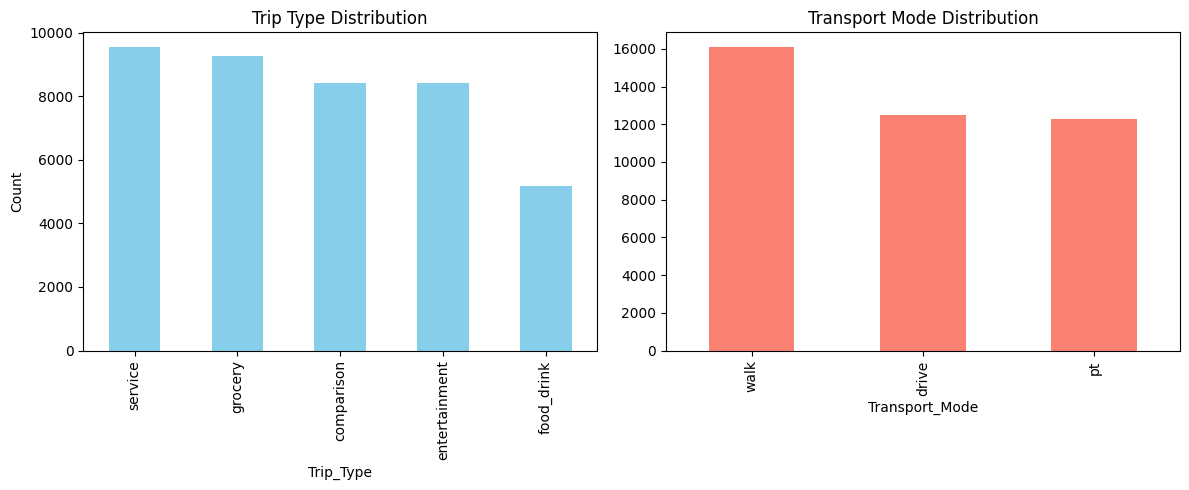

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_visits['Trip_Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Trip Type Distribution')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df_visits['Transport_Mode'].value_counts().plot(kind='bar', color='salmon')
plt.title('Transport Mode Distribution')

plt.tight_layout()
plt.show()



## 3. Demographic Analysis
Analyze how Age and Income relate to travel behaviour (Travel time/Distance).



In [4]:
# Merge demographics into visits
# Note: AgentID in visits corresponds to household in agents df
df_merged = df_visits.merge(df_agents[['household', 'age_years', 'salary_yearly']], 
                           left_on='AgentID', right_on='household', how='left')

# Age Bands
df_merged['Age_Band'] = pd.cut(df_merged['age_years'], 
                               bins=[0, 30, 50, 150], 
                               labels=['Young (<30)', 'Mid-Age (30-50)', 'Senior (50+)'])

# Income Quartiles
df_merged['Income_Quartile'] = pd.qcut(df_merged['salary_yearly'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])



ValueError: Bin edges must be unique: Index([0.0, 0.0, 1600.5834, 26053.078, 246571.7], dtype='float64', name='salary_yearly').
You can drop duplicate edges by setting the 'duplicates' kwarg

### Average Travel Time by Demographics



KeyError: 'Income_Quartile'

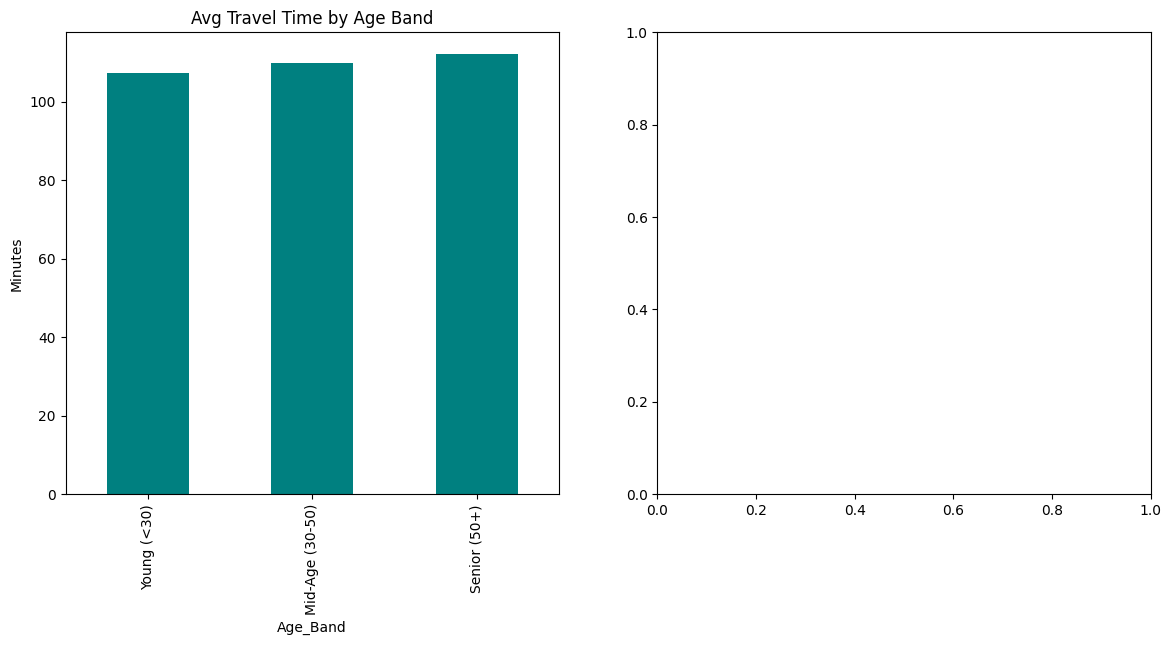

In [5]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df_merged.groupby('Age_Band', observed=True)['Travel_Time_Min'].mean().plot(kind='bar', color='teal')
plt.title('Avg Travel Time by Age Band')
plt.ylabel('Minutes')

plt.subplot(1, 2, 2)
df_merged.groupby('Income_Quartile', observed=True)['Travel_Time_Min'].mean().plot(kind='bar', color='orange')
plt.title('Avg Travel Time by Income Quartile')

plt.tight_layout()
plt.show()



## 4. Comparison to Reality (Retail Centre Attractiveness)
"Reality" Check: Larger centres (more POIs) should attract more visits.
We compare the simulation visit totals against the `Total_POI_` count.



In [6]:
# Aggregate visits by Retail_Centre
centre_visits = df_visits.groupby('Retail_Centre').size().reset_index(name='Visit_Count')
centre_visits['Retail_Centre'] = centre_visits['Retail_Centre'].astype(str)

# Merge with Retail Centre attributes
reality_df = gdf_retail.merge(centre_visits, left_on='RC_ID', right_on='Retail_Centre', how='left').fillna({'Visit_Count': 0})

# Correlation analysis
correlation = reality_df['Total_POI_'].corr(reality_df['Visit_Count'])
print(f"Correlation between Total POIs and Visit Count: {correlation:.3f}")



Correlation between Total POIs and Visit Count: 0.333


### Regression Plot: Visits vs. Reality (POI Count)



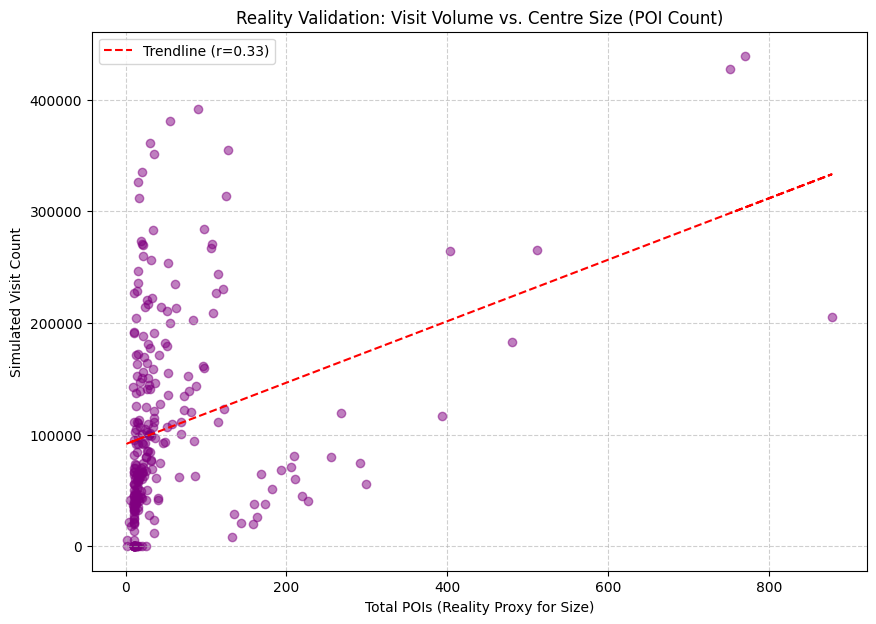

In [7]:
plt.figure(figsize=(10, 7))
plt.scatter(reality_df['Total_POI_'], reality_df['Visit_Count'], alpha=0.5, color='purple')

# Add trend line
z = np.polyfit(reality_df['Total_POI_'], reality_df['Visit_Count'], 1)
p = np.poly1d(z)
plt.plot(reality_df['Total_POI_'], p(reality_df['Total_POI_']), "r--", label=f"Trendline (r={correlation:.2f})")

plt.xlabel('Total POIs (Reality Proxy for Size)')
plt.ylabel('Simulated Visit Count')
plt.title('Reality Validation: Visit Volume vs. Centre Size (POI Count)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



## 5. Outlier Detection
Centres that are performing much better or worse than their size suggests.



In [8]:
reality_df['Residual'] = reality_df['Visit_Count'] - p(reality_df['Total_POI_'])
overperformers = reality_df.nlargest(5, 'Residual')[['RC_Name', 'Total_POI_', 'Visit_Count', 'Residual']]
underperformers = reality_df.nsmallest(5, 'Residual')[['RC_Name', 'Total_POI_', 'Visit_Count', 'Residual']]

print("\n--- Overperforming Centres (Attracting more than expected) ---")
print(overperformers)

print("\n--- Underperforming Centres (Attracting less than expected) ---")
print(underperformers)



KeyError: "['RC_Name'] not in index"

## 6. Distance Decay
Probability of visiting a centre relative to travel time.



C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2821154745.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Time_Bin'] = pd.cut(subset['Travel_Time_Min'], bins=range(0, 121, 5), labels=range(2, 121, 5))
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2821154745.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Time_Bin'] = pd.cut(subset['Travel_Time_Min'], bins=range(0, 121, 5), labels=range(2, 121, 5))
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2821154745.py:6: Sett

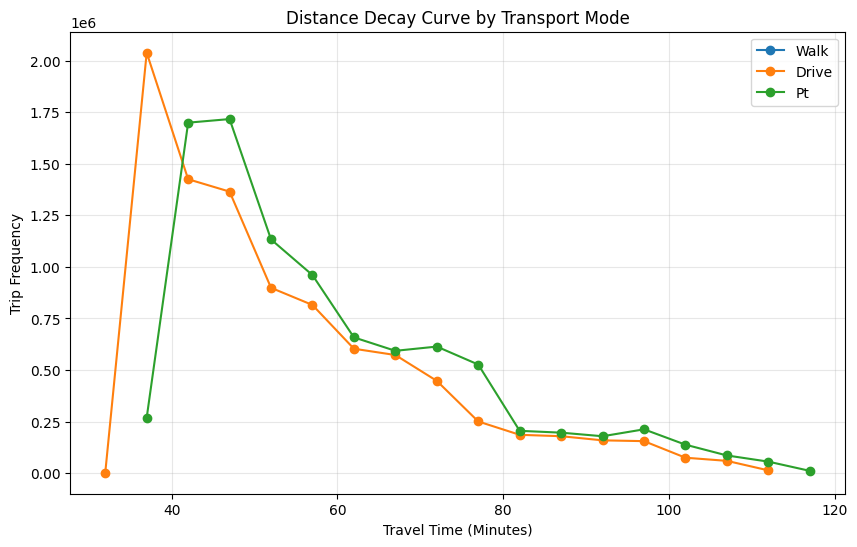

In [9]:
plt.figure(figsize=(10, 6))
for mode in ['walk', 'drive', 'pt']:
    subset = df_visits[df_visits['Transport_Mode'] == mode]
    if not subset.empty:
        # Create bins for travel time
        subset['Time_Bin'] = pd.cut(subset['Travel_Time_Min'], bins=range(0, 121, 5), labels=range(2, 121, 5))
        dist_counts = subset.groupby('Time_Bin', observed=True).size()
        plt.plot(dist_counts.index, dist_counts.values, marker='o', label=f'{mode.capitalize()}')

plt.xlabel('Travel Time (Minutes)')
plt.ylabel('Trip Frequency')
plt.title('Distance Decay Curve by Transport Mode')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
trips1 = r"C:\Users\sgabalog\Documents\P3\Model\Utility\utility_scores_bulk_with_trips.parquet"
df_input = pd.read_parquet(trips1)

In [17]:
print(list(df_input.columns))

['household', 'sex', 'age_years', 'nssec8', 'pwkstat', 'salary_yearly', 'id', 'num_children', 'household_size', 'Postcode', 'stock_level', 'consumption_rate', 'shopping_threshold', 'prob_convenience', 'prob_bulk', 'prob_online', 'amenity_type', 'channel_type', 'prob_walk', 'prob_drive', 'prob_pt', 'W_total', 'W_distance', 'W_personal_proffesional', 'W_cafe', 'W_retail', 'W_entertainment', 'W_restaurant', 'freq_comparison', 'prob_trip_comparison', 'freq_entertainment', 'prob_trip_entertainment', 'freq_service', 'prob_trip_service', 'freq_food_drink', 'prob_trip_food_drink', '6442.0_walk', '7143.0_walk', '1388.0_walk', '7611.0_walk', '5054.0_walk', '7608.0_walk', '6767.0_walk', '1000.0_walk', '4274.0_walk', '7141.0_walk', '7609.0_walk', '1222.0_walk', '5630.0_walk', '4443.0_walk', '5865.0_walk', '5866.0_walk', '4204.0_walk', '7163.0_walk', '8851.0_walk', '8177.0_walk', '4877.0_walk', '8151.0_walk', '547.0_walk', '90.0_walk', '5052.0_walk', '8805.0_walk', '3004.0_walk', '2230.0_walk', '16

In [27]:
import pandas as pd
import os

# Define the file path
file_path = r'C:\Users\sgabalog\Documents\P3\Model\Distance\Results\final_transport_times.parquet'

# 1. Read the parquet file
df = pd.read_parquet(file_path)

# 2. Save 1000 random lines (use replace=False to ensure unique rows)
# Note: If the file has fewer than 1000 rows, this will throw an error.
df_sample = df.sample(n=1000, random_state=42)

# 3. Define the new CSV path (changing the extension)
csv_path = file_path.replace('.parquet', '_sample.csv')

# 4. Save to CSV
df_sample.to_csv(csv_path, index=False)

print(f"Success! Sample saved to: {csv_path}")

Success! Sample saved to: C:\Users\sgabalog\Documents\P3\Model\Distance\Results\final_transport_times_sample.csv


In [29]:
# Define the file path
file_path = r'C:\Users\sgabalog\Documents\P3\Model\Utility\utility_scores_average.parquet'

# 1. Read the parquet file
df = pd.read_parquet(file_path)

In [30]:
df

,household,sex,age_years,nssec8,pwkstat,salary_yearly,id,num_children,household_size,Postcode,...,8176.0_pt,4325.0_pt,1010.0_pt,8852.0_pt,9356.0_pt,1566.0_pt,950.0_pt,288.0_pt,5856.0_pt,97.0_pt
0,0,MALE,74,NEVER,RETIRED,0.000,0,1,3,L33 4YT,...,0.005114,0.0,0.001997,0.0,0.001413,0.112073,0.033043,0.172357,0.0,0.255553
1,1,MALE,86,NEVER,RETIRED,0.000,3,0,1,L33 1UW,...,0.010141,0.0,0.002122,0.0,0.001299,0.137482,0.048323,0.267246,0.0,0.386265
2,2,FEMALE,71,SMALL,RETIRED,0.000,4,1,2,L33 4YU,...,0.008459,0.0,0.001128,0.0,0.000563,0.071369,0.032548,0.192128,0.0,0.264471
3,3,FEMALE,74,LOWER,RETIRED,0.000,6,1,2,L33 1RZ,...,0.009202,0.0,0.001584,0.0,0.000891,0.114519,0.041772,0.228800,0.0,0.336522
4,4,FEMALE,43,ROUTINE,EMPLOYEE_PT,9522.240,8,0,1,L33 9TY,...,0.020975,0.0,0.004885,0.0,0.003749,0.176070,0.063296,0.336092,0.0,0.485393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656812,656812,FEMALE,33,ROUTINE,LONG_TERM_SICK,0.000,1525919,0,2,WA7 2RP,...,0.385890,0.0,0.260033,0.0,0.401924,0.137931,0.065530,0.241657,0.0,0.350638
656813,656813,MALE,58,SEMIROUTINE,EMPLOYEE_FT,21312.795,1525921,0,2,WA7 3HX,...,0.099510,0.0,0.073957,0.0,0.127965,0.049556,0.021370,0.068804,0.0,0.116092
656814,656814,FEMALE,59,INTERMEDIATE,EMPLOYEE_FT,42868.547,1525923,0,2,WA7 3EH,...,0.026109,0.0,0.046845,0.0,0.070272,0.045175,0.011858,0.042752,0.0,0.063627
656815,656815,FEMALE,56,SMALL,EMPLOYEE_FT,20794.768,1525925,1,2,WA7 2RT,...,0.145390,0.0,0.095209,0.0,0.181801,0.055449,0.029110,0.087888,0.0,0.158870


In [43]:
import pandas as pd

# Assuming your original DataFrame is named 'df'
# 1. Create the subset where Postcode is 'L5 6PN'
subset_df = df[df['Postcode'] == 'L8 5AB']

# 2. Define the file path
# Note: Using 'r' before the string handles the backslashes correctly in Windows
file_path = r'C:\Users\sgabalog\Documents\P3\Model\Utility\testing_accuracy.csv'

# 3. Save the subset to the specified location
# index=False prevents pandas from writing row numbers into the CSV
subset_df.to_csv(file_path, index=False)

print(f"File successfully saved to: {file_path}")

File successfully saved to: C:\Users\sgabalog\Documents\P3\Model\Utility\testing_accuracy.csv


In [33]:
import pandas as pd

# 1. Assuming 'subset_df' is the subset where Postcode == 'L5 6PN'
# Filter to include only numeric columns (int and float)
numeric_subset = subset_df.select_dtypes(include=['number'])

# 2. Define a function for Range
def get_range(x):
    return x.max() - x.min()

# 3. Calculate Mean and Range for each numeric column
# We use .agg to apply multiple functions at once
stats = numeric_subset.agg(['mean', get_range])

# Optional: Rename 'get_range' to 'range' for a cleaner look
stats = stats.rename(index={'get_range': 'range'})

# Display the results
print("Summary Statistics for Postcode L5 6PN:")
print(stats)

# If you want to save these statistics to a CSV as well:
# stats.to_csv(r'C:\Users\sgabalog\Documents\P3\Model\Utility\subset_summary_stats.csv')

Summary Statistics for Postcode L5 6PN:
           household  age_years  salary_yearly             id  num_children  \
mean   116921.684211  54.368421   10937.953053  278995.263158      0.578947   
range    2338.000000  63.000000   36092.508000    5120.000000      2.000000   

       household_size  stock_level  consumption_rate  shopping_threshold  \
mean         1.894737    108.89550         22.313295           27.492165   
range        2.000000    111.15942         19.188984           28.137537   

       prob_convenience  ...  8176.0_pt  4325.0_pt  1010.0_pt  8852.0_pt  \
mean           1.176316  ...   0.008804        0.0   0.003570        0.0   
range          7.000000  ...   0.014581        0.0   0.007632        0.0   

       9356.0_pt  1566.0_pt  950.0_pt  288.0_pt  5856.0_pt   97.0_pt  
mean    0.003303   0.354471  0.136619  0.619498        0.0  0.949224  
range   0.006989   0.674638  0.247208  1.190336        0.0  1.727793  

[2 rows x 801 columns]


In [34]:
stats

,household,age_years,salary_yearly,id,num_children,household_size,stock_level,consumption_rate,shopping_threshold,prob_convenience,...,8176.0_pt,4325.0_pt,1010.0_pt,8852.0_pt,9356.0_pt,1566.0_pt,950.0_pt,288.0_pt,5856.0_pt,97.0_pt
mean,116921.684211,54.368421,10937.953053,278995.263158,0.578947,1.894737,108.89550,22.313295,27.492165,1.176316,...,0.008804,0.0,0.003570,0.0,0.003303,0.354471,0.136619,0.619498,0.0,0.949224
range,2338.000000,63.000000,36092.508000,5120.000000,2.000000,2.000000,111.15942,19.188984,28.137537,7.000000,...,0.014581,0.0,0.007632,0.0,0.006989,0.674638,0.247208,1.190336,0.0,1.727793


In [44]:
# 1. Filter for numeric columns in your subset
numeric_subset = subset_df.select_dtypes(include=['number'])

# 2. Calculate Highest (max), Lowest (min), and Mean
# We use 'min', 'max', and 'mean' strings which are built into pandas
summary_stats = numeric_subset.agg(['min', 'max', 'mean'])

# 3. Transpose for better readability (Columns as rows, Stats as columns)
summary_stats = summary_stats.T

# Rename columns for clarity
summary_stats.columns = ['Lowest', 'Highest', 'Mean']

# Display the results
print("Numeric Summary for Postcode L5 6PN:")
print(summary_stats)

Numeric Summary for Postcode L5 6PN:
                     Lowest       Highest          Mean
household      5.979080e+05  6.006540e+05  5.995449e+05
age_years      2.400000e+01  6.500000e+01  3.876923e+01
salary_yearly  0.000000e+00  1.107973e+05  3.805132e+04
id             1.388913e+06  1.393799e+06  1.391826e+06
num_children   0.000000e+00  1.000000e+00  1.538462e-01
...                     ...           ...           ...
1566.0_pt      8.002123e-02  1.182631e+00  5.362272e-01
950.0_pt       9.094903e-02  4.968634e-01  2.520770e-01
288.0_pt       3.444336e-01  1.869303e+00  8.758172e-01
5856.0_pt      0.000000e+00  0.000000e+00  0.000000e+00
97.0_pt        4.965605e-01  2.694669e+00  1.376220e+00

[801 rows x 3 columns]


In [39]:
import pandas as pd

# 1. Identify the specific columns ending with your keywords
# We filter the subset columns to find those ending in _pt, _walk, or _drive
target_cols = [c for c in subset_df.columns if c.endswith(('_pt', '_walk', '_drive'))]

# 2. Create a sub-dataframe with just these columns
transport_data = subset_df[target_cols]

# 3. Find the highest and lowest value for EACH ROW
# axis=1 tells pandas to look horizontally across columns
subset_df['Fastest_Mode_Val'] = transport_data.min(axis=1) # Assuming lower is better (e.g., time)
subset_df['Fastest_Mode_Name'] = transport_data.idxmin(axis=1)

subset_df['Slowest_Mode_Val'] = transport_data.max(axis=1)
subset_df['Slowest_Mode_Name'] = transport_data.idxmax(axis=1)

# 4. View the results for the first few rows
print(subset_df[['Postcode'] + target_cols + ['Fastest_Mode_Name', 'Fastest_Mode_Val']].head())

# 5. Save the updated subset with these new insights
output_path = r'C:\Users\sgabalog\Documents\P3\Model\Utility\transport_comparison.csv'
subset_df.to_csv(output_path, index=False)

       Postcode  prob_walk  prob_drive  prob_pt  6442.0_walk  7143.0_walk  \
115825   L5 6PN        0.5         0.5      0.5     0.101198     0.062605   
115894   L5 6PN        0.5         0.5      0.5     0.195646     0.086436   
116109   L5 6PN        0.5         0.5      0.5     0.050837     0.004329   
116413   L5 6PN        0.5         0.5      0.5     0.216761     0.133898   
116520   L5 6PN        0.5         0.5      0.5     0.202402     0.104406   

        1388.0_walk  7611.0_walk  5054.0_walk  7608.0_walk  ...  1010.0_pt  \
115825     0.138715     0.039948     0.035614     0.133071  ...   0.001603   
115894     0.303217     0.095457     0.064974     0.313266  ...   0.003826   
116109     0.096185     0.033721     0.014062     0.110650  ...   0.001255   
116413     0.271497     0.073796     0.094492     0.212655  ...   0.004054   
116520     0.270125     0.076568     0.076350     0.244923  ...   0.003356   

        8852.0_pt  9356.0_pt  1566.0_pt  950.0_pt  288.0_pt  5856.0_

C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2163653831.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Fastest_Mode_Val'] = transport_data.min(axis=1) # Assuming lower is better (e.g., time)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2163653831.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Fastest_Mode_Name'] = transport_data.idxmin(axis=1)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\2163653831.py:15: SettingWithCopyWarning: 
A value is trying to

In [45]:
import pandas as pd

# 1. Identify the target columns
target_cols = [c for c in subset_df.columns if c.endswith(('_pt', '_walk', '_drive'))]

# 2. Identify the "Winner" for every row in the subset
# This finds the column name with the highest value for each specific row
subset_df['Best_Mode_Name'] = subset_df[target_cols].idxmax(axis=1)
subset_df['Best_Mode_Value'] = subset_df[target_cols].max(axis=1)

# 3. Create a list to store the top 10s
top_10_list = []

for col in target_cols:
    # Get the top 10 rows for this specific column
    top_10 = subset_df.nlargest(10, col).copy()
    
    # Add a label so you know which ranking this row belongs to
    top_10['Top_Ten_Group'] = f'Top 10 for {col}'
    
    top_10_list.append(top_10)

# 4. Combine all top 10s into one DataFrame
final_top_10_df = pd.concat(top_10_list)

# 5. Save the result to your directory
output_path = r'C:\Users\sgabalog\Documents\P3\Model\Utility\top_10_transport_modes.csv'
final_top_10_df.to_csv(output_path, index=False)

# Display a preview of the columns requested
print("Top 10s successfully generated.")
print(final_top_10_df[['Top_Ten_Group', 'Best_Mode_Name', 'Best_Mode_Value']].head(15))

C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\3469567798.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Best_Mode_Name'] = subset_df[target_cols].idxmax(axis=1)
C:\Users\sgabalog\AppData\Local\Temp\ipykernel_19440\3469567798.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df['Best_Mode_Value'] = subset_df[target_cols].max(axis=1)


Top 10s successfully generated.
                Top_Ten_Group Best_Mode_Name  Best_Mode_Value
597908   Top 10 for prob_walk     90.0_drive         0.706804
598096   Top 10 for prob_walk     90.0_drive         1.240528
598405   Top 10 for prob_walk     90.0_drive         1.838898
599056   Top 10 for prob_walk     90.0_drive         0.861116
599057   Top 10 for prob_walk     90.0_drive         1.331786
599529   Top 10 for prob_walk     90.0_drive         0.848732
599786   Top 10 for prob_walk     90.0_drive         2.762265
600109   Top 10 for prob_walk     90.0_drive         1.546056
600184   Top 10 for prob_walk     90.0_drive         0.868331
600421   Top 10 for prob_walk     90.0_drive         0.522059
597908  Top 10 for prob_drive     90.0_drive         0.706804
598096  Top 10 for prob_drive     90.0_drive         1.240528
598405  Top 10 for prob_drive     90.0_drive         1.838898
599056  Top 10 for prob_drive     90.0_drive         0.861116
599057  Top 10 for prob_drive     90.0

In [41]:
final_top_10_df

,household,sex,age_years,nssec8,pwkstat,salary_yearly,id,num_children,household_size,Postcode,...,288.0_pt,5856.0_pt,97.0_pt,Fastest_Mode_Val,Fastest_Mode_Name,Slowest_Mode_Val,Slowest_Mode_Name,Best_Mode_Name,Best_Mode_Value,Top_Ten_Group
115825,115825,FEMALE,83,INTERMEDIATE,RETIRED,0.000,276656,0,1,L5 6PN,...,0.295978,0.0,0.460677,0.00000,8805.0_walk,0.559329,3883.0_drive,3883.0_drive,0.559329,Top 10 for prob_walk
115894,115894,FEMALE,50,NEVER,HOMEMAKER,0.000,276780,1,2,L5 6PN,...,0.705915,0.0,0.884059,0.00000,8805.0_walk,1.081279,3883.0_drive,3883.0_drive,1.081279,Top 10 for prob_walk
116109,116109,MALE,68,SEMIROUTINE,RETIRED,0.000,277265,0,2,L5 6PN,...,0.253436,0.0,0.228648,0.00000,8805.0_walk,0.500000,prob_walk,prob_walk,0.500000,Top 10 for prob_walk
116413,116413,MALE,60,SMALL,EMPLOYEE_PT,7410.053,277924,0,1,L5 6PN,...,0.453284,0.0,0.940225,-0.00078,9576.0_drive,1.139652,90.0_drive,90.0_drive,1.139652,Top 10 for prob_walk
116520,116520,FEMALE,64,NEVER,EMPLOYEE_FT,16929.703,278227,1,2,L5 6PN,...,0.538645,0.0,0.907310,0.00000,8805.0_walk,1.076240,3883.0_drive,3883.0_drive,1.076240,Top 10 for prob_walk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116933,116933,FEMALE,55,SEMIROUTINE,EMPLOYEE_FT,29939.102,278952,1,2,L5 6PN,...,1.036772,0.0,1.421585,0.00000,8805.0_walk,1.638577,3883.0_drive,3883.0_drive,1.638577,Top 10 for 97.0_pt
116413,116413,MALE,60,SMALL,EMPLOYEE_PT,7410.053,277924,0,1,L5 6PN,...,0.453284,0.0,0.940225,-0.00078,9576.0_drive,1.139652,90.0_drive,90.0_drive,1.139652,Top 10 for 97.0_pt
116520,116520,FEMALE,64,NEVER,EMPLOYEE_FT,16929.703,278227,1,2,L5 6PN,...,0.538645,0.0,0.907310,0.00000,8805.0_walk,1.076240,3883.0_drive,3883.0_drive,1.076240,Top 10 for 97.0_pt
116857,116857,MALE,70,ROUTINE,EMPLOYEE_PT,0.000,278812,1,3,L5 6PN,...,0.485791,0.0,0.905895,0.00000,8805.0_walk,1.084181,90.0_drive,90.0_drive,1.084181,Top 10 for 97.0_pt


In [ ]:
file = r"C:\Users\sgabalog\Documents\P3\Model\Utility\consumer_agents_bulk.parquet"
para_full = pd.read_parquet(file)

In [15]:
import pandas as pd

file = r"c:\Users\sgabalog\Documents\P3\Model\Utility\utility_scores_average.parquet"

# Use the pyarrow engine to read the first 1000 rows
para_full = pd.read_parquet(file, engine='pyarrow')

In [16]:
para_full

,household,sex,age_years,nssec8,pwkstat,salary_yearly,id,num_children,household_size,Postcode,...,8176.0_pt,4325.0_pt,1010.0_pt,8852.0_pt,9356.0_pt,1566.0_pt,950.0_pt,288.0_pt,5856.0_pt,97.0_pt
0,0,MALE,74,NEVER,RETIRED,0.000,0,1,3,L33 4YT,...,0.005114,0.0,0.001997,0.0,0.001413,0.112073,0.033043,0.172357,0.0,0.255553
1,1,MALE,86,NEVER,RETIRED,0.000,3,0,1,L33 1UW,...,0.010141,0.0,0.002122,0.0,0.001299,0.137482,0.048323,0.267246,0.0,0.386265
2,2,FEMALE,71,SMALL,RETIRED,0.000,4,1,2,L33 4YU,...,0.008459,0.0,0.001128,0.0,0.000563,0.071369,0.032548,0.192128,0.0,0.264471
3,3,FEMALE,74,LOWER,RETIRED,0.000,6,1,2,L33 1RZ,...,0.009202,0.0,0.001584,0.0,0.000891,0.114519,0.041772,0.228800,0.0,0.336522
4,4,FEMALE,43,ROUTINE,EMPLOYEE_PT,9522.240,8,0,1,L33 9TY,...,0.020975,0.0,0.004885,0.0,0.003749,0.176070,0.063296,0.336092,0.0,0.485393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656812,656812,FEMALE,33,ROUTINE,LONG_TERM_SICK,0.000,1525919,0,2,WA7 2RP,...,0.385890,0.0,0.260033,0.0,0.401924,0.137931,0.065530,0.241657,0.0,0.350638
656813,656813,MALE,58,SEMIROUTINE,EMPLOYEE_FT,21312.795,1525921,0,2,WA7 3HX,...,0.099510,0.0,0.073957,0.0,0.127965,0.049556,0.021370,0.068804,0.0,0.116092
656814,656814,FEMALE,59,INTERMEDIATE,EMPLOYEE_FT,42868.547,1525923,0,2,WA7 3EH,...,0.026109,0.0,0.046845,0.0,0.070272,0.045175,0.011858,0.042752,0.0,0.063627
656815,656815,FEMALE,56,SMALL,EMPLOYEE_FT,20794.768,1525925,1,2,WA7 2RT,...,0.145390,0.0,0.095209,0.0,0.181801,0.055449,0.029110,0.087888,0.0,0.158870


In [17]:
para_full = para_full[para_full['Postcode'] == "L3 4EB"]

# Display the first few rows of the filtered data
print(para_full.head())

        household     sex  age_years  nssec8      pwkstat  salary_yearly  \
597643     597643    MALE         39   LOWER  EMPLOYEE_FT      66805.150   
597671     597671  FEMALE         28   LOWER  EMPLOYEE_FT      76328.836   
597823     597823  FEMALE         26  HIGHER   STUDENT_FT          0.000   
597985     597985    MALE         61  HIGHER      RETIRED          0.000   
598092     598092    MALE         46  HIGHER    PWK_OTHER          0.000   

             id  num_children  household_size Postcode  ...  8176.0_pt  \
597643  1388431             0               2   L3 4EB  ...   0.001190   
597671  1388474             0               1   L3 4EB  ...   0.010742   
597823  1388747             0               2   L3 4EB  ...   0.015584   
597985  1389035             0               1   L3 4EB  ...   0.015701   
598092  1389236             1               3   L3 4EB  ...   0.002480   

        4325.0_pt  1010.0_pt  8852.0_pt  9356.0_pt  1566.0_pt  950.0_pt  \
597643        0.0   0.0

In [18]:
para_full.to_csv(r"C:\Users\sgabalog\Documents\P3\Model\Utility\to_be_deleted.csv")

In [2]:
import pandas as pd
results = pd.read_parquet(r"C:\Users\sgabalog\Documents\P3\Model\Retail_ABM\outputs\visits_log_1775642267.parquet")

In [4]:
results.head(50)

,Day,AgentID,Postcode,Trip_Type,Retail_Centre,Grocery_Mode,Transport_Mode,Travel_Time_Min,Utility_Modifier
0,1,2844,L33 8YL,grocery,8147,convenience,drive,48.630501,1.05
1,1,597550,L1 8AH,grocery,8820,convenience,walk,154.182083,1.05
2,1,503672,CH41 3QH,grocery,1974,convenience,pt,47.827259,0.95
3,1,384619,L38 1QQ,grocery,1453,bulk,walk,257.417114,1.05
4,1,506371,CH41 5EH,grocery,90,convenience,walk,160.608490,1.05
5,1,197025,L15 6UA,grocery,730,convenience,pt,44.256874,1.05
6,1,299751,WA10 1GN,grocery,7143,convenience,walk,266.913513,1.05
7,1,507901,CH46 0RT,grocery,3533,convenience,pt,60.712318,1.05
8,1,360856,PR8 6QD,grocery,6966,bulk,walk,441.261047,0.95
9,1,203600,L17 3DA,grocery,1281,convenience,walk,156.809967,0.95


In [5]:
# Filter the DataFrame for rows where AgentID is 0
filtered_results = results[results['Postcode'] == "L3 4EB"]

# Display the first few rows of the filtered data
print(filtered_results.head())

     Day  AgentID Postcode Trip_Type Retail_Centre Grocery_Mode  \
34     1   597671   L3 4EB   service          4204     physical   
145    2   597671   L3 4EB   grocery          7144  convenience   
193    2   597671   L3 4EB   service          4592     physical   
336    3   597671   L3 4EB   service          1245     physical   
445    4   597671   L3 4EB   grocery           224         bulk   

    Transport_Mode  Travel_Time_Min  Utility_Modifier  
34           drive        40.996525              0.95  
145          drive        40.996525              1.05  
193          drive        40.996525              1.05  
336             pt        45.085636              1.05  
445             pt        45.085636              1.05  


In [6]:
filtered_results.to_csv(r"C:\Users\sgabalog\Documents\P3\Model\Utility\results_to_be_deleted.csv")